# Loan Approval Model (LendingClub Dataset)

This notebook builds and evaluates multiple classification models to support loan approval decisions.

Models covered:
- Logistic Regression
- Random Forest
- SVM (LinearSVC)
- LightGBM
- XGBoost

Evaluation metrics:
- Accuracy
- Precision
- Recall
- F1
- ROC-AUC
- PR-AUC

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    RocCurveDisplay,
    PrecisionRecallDisplay,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import inspect
import warnings
warnings.filterwarnings('ignore')


SEED = 69
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 200)

In [4]:
# Load data
df = pd.read_csv('loan_data.csv', low_memory=False)
print(f'Shape: {df.shape}')
df.info(memory_usage='deep')

Shape: (39717, 111)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39717 entries, 0 to 39716
Columns: 111 entries, id to total_il_high_credit_limit
dtypes: float64(74), int64(13), object(24)
memory usage: 95.9 MB


In [5]:
df.head()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_il_6m,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m,acc_open_past_24mths,avg_cur_bal,bc_open_to_buy,bc_util,chargeoff_within_12_mths,delinq_amnt,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,mths_since_recent_bc_dlq,mths_since_recent_inq,mths_since_recent_revol_delinq,num_accts_ever_120_pd,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit
0,1077501,1296599,5000,5000,4975.0,36 months,10.65%,162.87,B,B2,NaN,10+ years,RENT,24000.0,Verified,Dec-11,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,Borrower added on 12/22/11 > I need to upgra...,credit_card,Computer,860xx,AZ,27.65,0,Jan-85,1,NaN,NaN,3,0,13648,83.70%,9,f,0.00,0.00,5863.155187,5833.84,5000.00,863.16,0.00,0.00,0.00,Jan-15,171.62,NaN,May-16,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN
1,1077430,1314167,2500,2500,2500.0,60 months,15.27%,59.83,C,C4,Ryder,< 1 year,RENT,30000.0,Source Verified,Dec-11,Charged Off,n,https://lendingclub.com/browse/loanDetail.acti...,Borrower added on 12/22/11 > I plan to use t...,car,bike,309xx,GA,1.00,0,Apr-99,5,NaN,NaN,3,0,1687,9.40%,4,f,0.00,0.00,1008.710000,1008.71,456.46,435.17,0.00,117.08,1.11,Apr-13,119.66,NaN,Sep-13,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN
2,1077175,1313524,2400,2400,2400.0,36 months,15.96%,84.33,C,C5,NaN,10+ years,RENT,12252.0,Not Verified,Dec-11,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,small_business,real estate business,606xx,IL,8.72,0,Nov-01,2,NaN,NaN,2,0,2956,98.50%,10,f,0.00,0.00,3005.666844,3005.67,2400.00,605.67,0.00,0.00,0.00,Jun-14,649.91,NaN,May-16,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN
3,1076863,1277178,10000,10000,10000.0,36 months,13.49%,339.31,C,C1,AIR RESOURCES BOARD,10+ years,RENT,49200.0,Source Verified,Dec-11,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,Borrower added on 12/21/11 > to pay for prop...,other,personel,917xx,CA,20.00,0,Feb-96,1,35.0,NaN,10,0,5598,21%,37,f,0.00,0.00,12231.890000,12231.89,10000.00,2214.92,16.97,0.00,0.00,Jan-15,357.48,NaN,Apr-16,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN

In [6]:
# Load data dictionary
dd = pd.read_excel('Data_Dictionary.xlsx')
display(dd.head(10))

,LoanStatNew,Description
0,acc_now_delinq,The number of accounts on which the borrower i...
1,acc_open_past_24mths,Number of trades opened in past 24 months.
2,addr_state,The state provided by the borrower in the loan...
3,all_util,Balance to credit limit on all trades
4,annual_inc,The self-reported annual income provided by th...
5,annual_inc_joint,The combined self-reported annual income provi...
6,application_type,Indicates whether the loan is an individual ap...
7,avg_cur_bal,Average current balance of all accounts
8,bc_open_to_buy,Total open to buy on revolving bankcards.
9,bc_util,Ratio of total current balance to high credit/...


In [7]:
for c in df.columns:
    print(c)

id
member_id
loan_amnt
funded_amnt
funded_amnt_inv
term
int_rate
installment
grade
sub_grade
emp_title
emp_length
home_ownership
annual_inc
verification_status
issue_d
loan_status
pymnt_plan
url
desc
purpose
title
zip_code
addr_state
dti
delinq_2yrs
earliest_cr_line
inq_last_6mths
mths_since_last_delinq
mths_since_last_record
open_acc
pub_rec
revol_bal
revol_util
total_acc
initial_list_status
out_prncp
out_prncp_inv
total_pymnt
total_pymnt_inv
total_rec_prncp
total_rec_int
total_rec_late_fee
recoveries
collection_recovery_fee
last_pymnt_d
last_pymnt_amnt
next_pymnt_d
last_credit_pull_d
collections_12_mths_ex_med
mths_since_last_major_derog
policy_code
application_type
annual_inc_joint
dti_joint
verification_status_joint
acc_now_delinq
tot_coll_amt
tot_cur_bal
open_acc_6m
open_il_6m
open_il_12m
open_il_24m
mths_since_rcnt_il
total_bal_il
il_util
open_rv_12m
open_rv_24m
max_bal_bc
all_util
total_rev_hi_lim
inq_fi
total_cu_tl
inq_last_12m
acc_open_past_24mths
avg_cur_bal
bc_open_to_buy
bc

Upon inspection it is clear that we must derive our target feature from `'loan_status'`

In [9]:
# Target engineering: default risk (1 = bad loan, 0 = good loan)

y = df['loan_status'].map(
    {'Charged Off': 1, 'Fully Paid': 0, 'Current': 0}).astype('int8')
display(y.value_counts())

print(f'Rate of Defaulting: {y.mean():.2%}')

loan_status
0    34090
1     5627
Name: count, dtype: int64

Rate of Defaulting: 14.17%


In [10]:
# Remove columns that leak post-loan outcomes, identifiers/text-heavy features and target etc that are not useful for modeling
removable_cols = [
    'loan_status',
    'id',
    'member_id',
    'url',
    'desc',
    'funded_amnt',
    'funded_amnt_inv',
    'out_prncp',
    'out_prncp_inv',
    'total_pymnt',
    'total_pymnt_inv',
    'total_rec_prncp',
    'total_rec_int',
    'total_rec_late_fee',
    'recoveries',
    'collection_recovery_fee',
    'last_pymnt_d',
    'last_pymnt_amnt',
    'next_pymnt_d',
    'last_credit_pull_d'
]

X = df.drop(
    columns=[c for c in removable_cols if c in df.columns], errors='ignore')

In [12]:
# Drop very high-missing columns to simplify and stabilize one-hot encoding
threshold = 0.7
print('Feature matrix shape before filtering:', X.shape)
missing_ratio = X.isna().mean().sort_values(ascending=False)
high_missing_cols = missing_ratio[missing_ratio > threshold].index.tolist()
# X = X.drop(columns=high_missing_cols)
# print('Feature matrix shape after filtering:', X.shape)
print('No of dropped high-missing columns:', len(high_missing_cols))

Feature matrix shape before filtering: (39717, 91)
No of dropped high-missing columns: 55


In [15]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=SEED,
    stratify=y
)

num_cols = X_train.select_dtypes(include=['number']).columns.tolist()
cat_cols = [c for c in X_train.columns if c not in num_cols]

print('Train shape:', X_train.shape)
print('Test shape:', X_test.shape)
print('Numeric columns:', len(num_cols))
print('Categorical columns:', len(cat_cols))

Train shape: (31773, 91)
Test shape: (7944, 91)
Numeric columns: 73
Categorical columns: 18


In [16]:
# Compatibility-safe OneHotEncoder args across sklearn versions
ohe_params = {'handle_unknown': 'ignore', 'sparse_output': True}

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(**ohe_params))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols),
    ]
)

In [21]:
# Define candidate models
models = {
    'LogisticRegression': LogisticRegression(max_iter=2000, class_weight='balanced', random_state=SEED),
    'LinearSVC': LinearSVC(C=1.0, class_weight='balanced', max_iter=2000),
    'RandomForest': RandomForestClassifier(n_estimators=300, class_weight='balanced_subsample', n_jobs=-1, random_state=SEED),
    'LightGBM': LGBMClassifier(n_estimators=400, random_state=SEED, force_row_wise=True),
    'XGBoost': XGBClassifier(n_estimators=400, learning_rate=0.05, max_depth=5, subsample=0.8, colsample_bytree=0.8,
                             eval_metric='logloss',
                             random_state=SEED,
                             n_jobs=-1)
}

In [22]:
# Train and evaluate
results = []
fitted_pipelines = {}

for model_name, model in models.items():
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    print(f'Training: {model_name}..')
    pipe.fit(X_train, y_train)
    fitted_pipelines[model_name] = pipe

    y_pred = pipe.predict(X_test)
    if hasattr(pipe, 'predict_proba'):
        y_prob = pipe.predict_proba(X_test)[:, 1]
    else:
        scores = pipe.decision_function(X_test)
        y_prob = (scores - scores.min()) / (scores.max() - scores.min() + 1e-9)

    row = {
        'model': model_name,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall': recall_score(y_test, y_pred, zero_division=0),
        'f1': f1_score(y_test, y_pred, zero_division=0),
        'roc_auc': roc_auc_score(y_test, y_prob),
        'pr_auc': average_precision_score(y_test, y_prob),
    }
    results.append(row)

results_df = pd.DataFrame(results).sort_values(
    'roc_auc', ascending=False).reset_index(drop=True)
display(results_df)

Training: LogisticRegression..
Training: LinearSVC..
Training: RandomForest..
Training: LightGBM..
[LightGBM] [Info] Number of positive: 4502, number of negative: 27271
[LightGBM] [Info] Total Bins 5908
[LightGBM] [Info] Number of data points in the train set: 31773, number of used features: 2196
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.141693 -> initscore=-1.801302
[LightGBM] [Info] Start training from score -1.801302
Training: XGBoost..


,model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,XGBoost,0.856621,0.294118,0.008889,0.017256,0.699968,0.259732
1,RandomForest,0.858384,0.000000,0.000000,0.000000,0.694908,0.258275
2,LightGBM,0.855992,0.411215,0.039111,0.071429,0.672183,0.242191
3,LogisticRegression,0.757049,0.253521,0.368000,0.300218,0.658923,0.228656
4,LinearSVC,0.797080,0.228540,0.182222,0.202770,0.631408,0.210584


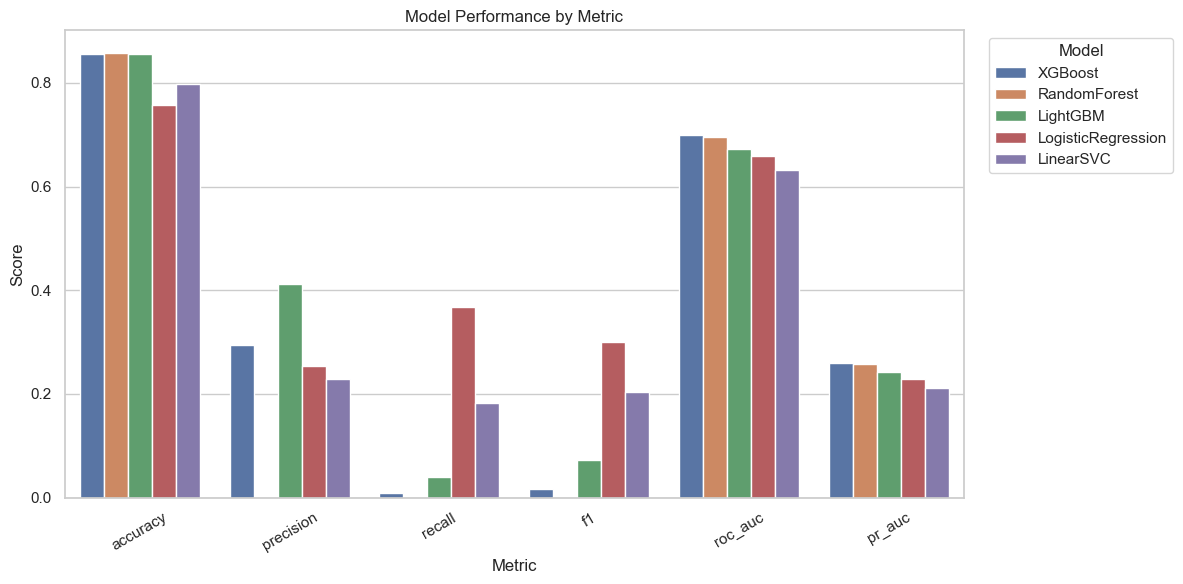

In [23]:
# Plot metrics on x-axis with model-wise clustered bars
metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'pr_auc']
results_melted = results_df.melt(
    id_vars='model',
    value_vars=metrics,
    var_name='metric',
    value_name='score'
)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=results_melted,
    x='metric',
    y='score',
    hue='model'
)
plt.title('Model Performance by Metric')
plt.xlabel('Metric')
plt.ylabel('Score')
plt.xticks(rotation=30)
plt.legend(title='Model', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

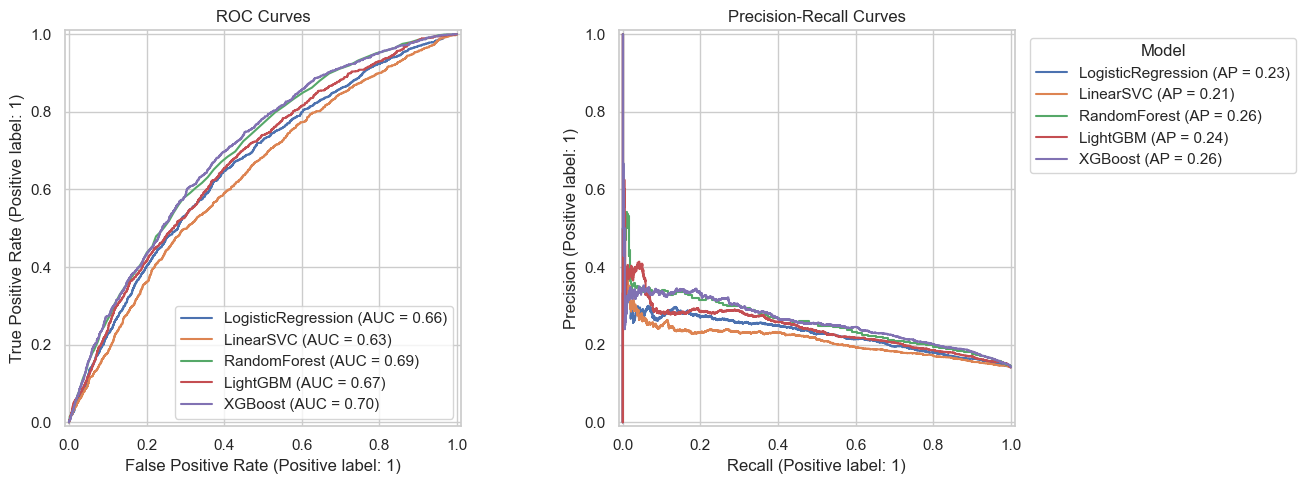

In [24]:
# ROC and PR curves for all models
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for model_name, pipe in fitted_pipelines.items():
    if hasattr(pipe, 'predict_proba'):
        y_prob = pipe.predict_proba(X_test)[:, 1]
    else:
        scores = pipe.decision_function(X_test)
        y_prob = (scores - scores.min()) / (scores.max() - scores.min() + 1e-9)

    RocCurveDisplay.from_predictions(
        y_test, y_prob, name=model_name, ax=axes[0])
    PrecisionRecallDisplay.from_predictions(
        y_test, y_prob, name=model_name, ax=axes[1])

axes[0].set_title('ROC Curves')
axes[1].set_title('Precision-Recall Curves')
axes[1].legend(title='Model', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

,threshold,precision,recall,f1
0,0.10,0.196074,0.825778,0.316903
1,0.15,0.239358,0.609778,0.343773
2,0.20,0.267221,0.400000,0.320399
3,0.25,0.319872,0.267556,0.291384
4,0.30,0.340681,0.151111,0.209360
5,0.35,0.330544,0.070222,0.115836
6,0.40,0.318966,0.032889,0.059629
7,0.45,0.348485,0.020444,0.038623
8,0.50,0.294118,0.008889,0.017256
9,0.55,0.454545,0.004444,0.008803


Best model: XGBoost
Selected threshold: 0.25


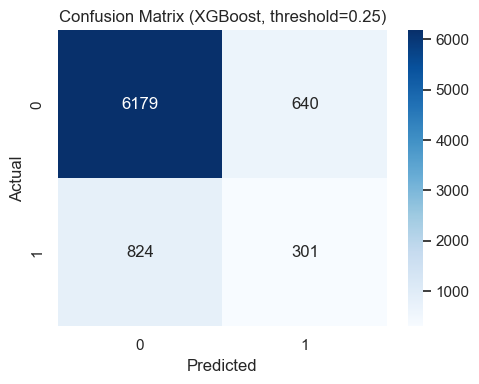

In [25]:
# Threshold tuning on best model (maximize recall under precision floor)
best_model_name = results_df.loc[0, 'model']
best_pipe = fitted_pipelines[best_model_name]

if hasattr(best_pipe, 'predict_proba'):
    y_prob_best = best_pipe.predict_proba(X_test)[:, 1]
else:
    scores = best_pipe.decision_function(X_test)
    y_prob_best = (scores - scores.min()) / \
        (scores.max() - scores.min() + 1e-9)

rows = []
for t in np.arange(0.10, 0.91, 0.05):
    y_pred_t = (y_prob_best >= t).astype(int)
    rows.append({
        'threshold': round(float(t), 2),
        'precision': precision_score(y_test, y_pred_t, zero_division=0),
        'recall': recall_score(y_test, y_pred_t, zero_division=0),
        'f1': f1_score(y_test, y_pred_t, zero_division=0),
    })

threshold_df = pd.DataFrame(rows)
display(threshold_df)

# Example business policy: precision >= 0.30 and maximize recall
candidate = threshold_df[threshold_df['precision'] >= 0.30]
if len(candidate) > 0:
    selected_row = candidate.sort_values('recall', ascending=False).iloc[0]
else:
    selected_row = threshold_df.sort_values('f1', ascending=False).iloc[0]

selected_threshold = float(selected_row['threshold'])
print('Best model:', best_model_name)
print('Selected threshold:', selected_threshold)

y_pred_selected = (y_prob_best >= selected_threshold).astype(int)
cm = confusion_matrix(y_test, y_pred_selected)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(
    f'Confusion Matrix ({best_model_name}, threshold={selected_threshold:.2f})')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [26]:
import optuna
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Optuna tuning for XGBoost (optimize ROC-AUC via CV on training set)


def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 800),
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.2, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "gamma": trial.suggest_float("gamma", 0.0, 5.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
    }

    xgb_trial = XGBClassifier(
        eval_metric="logloss",
        random_state=SEED,
        n_jobs=-1,
        **params
    )

    pipe_trial = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", xgb_trial)
    ])

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
    cv_scores = cross_val_score(
        pipe_trial, X_train, y_train,
        cv=cv, scoring="roc_auc", n_jobs=1
    )
    return cv_scores.mean()


study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=SEED)
)
study.optimize(objective, n_trials=30, show_progress_bar=True)

print("Best CV ROC-AUC:", study.best_value)
print("Best params:", study.best_params)

# Train tuned model on full training data
best_xgb_optuna = XGBClassifier(
    eval_metric="logloss",
    random_state=SEED,
    n_jobs=-1,
    **study.best_params
)

best_xgb_optuna_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", best_xgb_optuna)
])
best_xgb_optuna_pipe.fit(X_train, y_train)

# Evaluate on test set
y_prob_optuna = best_xgb_optuna_pipe.predict_proba(X_test)[:, 1]
# threshold_to_use = selected_threshold if "selected_threshold" in globals() else 0.5
threshold_to_use = 0.5
y_pred_optuna = (y_prob_optuna >= threshold_to_use).astype(int)

optuna_metrics = {
    "model": "XGBoost_Optuna",
    "threshold": threshold_to_use,
    "accuracy": accuracy_score(y_test, y_pred_optuna),
    "precision": precision_score(y_test, y_pred_optuna, zero_division=0),
    "recall": recall_score(y_test, y_pred_optuna, zero_division=0),
    "f1": f1_score(y_test, y_pred_optuna, zero_division=0),
    "roc_auc": roc_auc_score(y_test, y_prob_optuna),
    "pr_auc": average_precision_score(y_test, y_prob_optuna),
}
display(pd.DataFrame([optuna_metrics]))

# Optional: store for later plots/comparisons
# fitted_pipelines["XGBoost_Optuna"] = best_xgb_optuna_pipe

[I 2026-03-25 19:03:03,724] A new study created in memory with name: no-name-8f318c47-3f98-458f-9745-ea8bfafa521c


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-03-25 19:03:12,730] Trial 0 finished with value: 0.6926777667291232 and parameters: {'n_estimators': 378, 'learning_rate': 0.07272589628908209, 'max_depth': 5, 'min_child_weight': 8, 'subsample': 0.824539590308229, 'colsample_bytree': 0.7014355816880532, 'gamma': 0.5248854184255453, 'reg_alpha': 3.3585093582848466e-08, 'reg_lambda': 0.011471796303330607}. Best is trial 0 with value: 0.6926777667291232.
[I 2026-03-25 19:03:33,520] Trial 1 finished with value: 0.6775061606192515 and parameters: {'n_estimators': 619, 'learning_rate': 0.04854630020719004, 'max_depth': 9, 'min_child_weight': 1, 'subsample': 0.7270722386479856, 'colsample_bytree': 0.8964093108734508, 'gamma': 1.64247114587524, 'reg_alpha': 0.00017033714518294968, 'reg_lambda': 4.263550973414993e-07}. Best is trial 0 with value: 0.6926777667291232.
[I 2026-03-25 19:03:49,646] Trial 2 finished with value: 0.6979388498233633 and parameters: {'n_estimators': 394, 'learning_rate': 0.01113660228142777, 'max_depth': 7, 'min

,model,threshold,accuracy,precision,recall,f1,roc_auc,pr_auc
0,XGBoost_Optuna,0.5,0.85788,0.409091,0.008,0.015693,0.702972,0.266492


In [ ]:
# business-level insights
df['target_default'] = y
analysis_df = df.copy()


def safe_default_rate(group_col, top_n=10):
    if group_col in analysis_df.columns:
        tmp = (analysis_df
               .groupby(group_col)['target_default']
               .agg(['count', 'mean'])
               .rename(columns={'mean': 'default_rate'})
               .sort_values(['count', 'default_rate'], ascending=[False, False])
               .head(top_n))
        return tmp
    return pd.DataFrame()


print('Overall default rate:', round(analysis_df['target_default'].mean(), 4))

print('\nDefault rate by grade:')
display(safe_default_rate('grade', top_n=20))

print('\nDefault rate by term:')
display(safe_default_rate('term', top_n=20))

print('\nDefault rate by verification_status:')
display(safe_default_rate('verification_status', top_n=20))

print('\nDefault rate by purpose:')
display(safe_default_rate('purpose', top_n=20))

Overall default rate: 0.1417

Default rate by grade:


,count,default_rate
grade,,
B,12020,0.118552
A,10085,0.059693
C,8098,0.166337
D,5307,0.210665
E,2842,0.251583
F,1049,0.304099
G,316,0.319620



Default rate by term:


,count,default_rate
term,,
36 months,29096,0.110909
60 months,10621,0.225967



Default rate by verification_status:


,count,default_rate
verification_status,,
Not Verified,16921,0.126588
Verified,12809,0.160122
Source Verified,9987,0.143587



Default rate by purpose:


,count,default_rate
purpose,,
debt_consolidation,18641,0.148436
credit_card,5130,0.105653
other,3993,0.158527
home_improvement,2976,0.116599
major_purchase,2187,0.101509
small_business,1828,0.259847
car,1549,0.103292
wedding,947,0.101373
medical,693,0.152958


## Insights and Recommendations

Use the model results and slice analysis above to finalize decisions. Typical patterns in LendingClub-style data often include:

1. **Risk segmentation matters**: grades/sub-grades usually show strong separation in default rates.
2. **Term effect**: 60-month loans often carry higher default risk than 36-month loans.
3. **Threshold policy over raw accuracy**: for approvals, tune threshold to optimize recall of risky applicants while keeping precision acceptable.
4. **Operational policy**: define multiple actions by score band:
   - Low risk: auto-approve
   - Medium risk: manual review + additional documents
   - High risk: decline or offer lower amount/higher rate
5. **Monitoring**: retrain quarterly and monitor drift in applicant profile and default rate.
6. **Purpose-Based** : most number of defaulters have the purpose of debt consolidation. However, the highest default rate is for small business loans (over 25%).
